In [1]:
import pandas as pd

data = {
    "Date": ["2026-01", "2026-02", "2026-03", "2026-04", "2026-05", "2026-06"],
    "Revenue": [500000, 550000, 600000, 580000, 650000, 700000],
    "Expenses": [350000, 370000, 390000, 380000, 410000, 430000],
    "Assets": [2000000, 2100000, 2200000, 2250000, 2350000, 2500000],
    "Liabilities": [800000, 820000, 850000, 830000, 870000, 900000],
    "Equity": [1200000, 1280000, 1350000, 1420000, 1480000, 1600000]
}

df = pd.DataFrame(data)

df

,Date,Revenue,Expenses,Assets,Liabilities,Equity
0,2026-01,500000,350000,2000000,800000,1200000
1,2026-02,550000,370000,2100000,820000,1280000
2,2026-03,600000,390000,2200000,850000,1350000
3,2026-04,580000,380000,2250000,830000,1420000
4,2026-05,650000,410000,2350000,870000,1480000
5,2026-06,700000,430000,2500000,900000,1600000


In [2]:
df["Profit"] = df["Revenue"] - df["Expenses"]

df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit
0,2026-01,500000,350000,2000000,800000,1200000,150000
1,2026-02,550000,370000,2100000,820000,1280000,180000
2,2026-03,600000,390000,2200000,850000,1350000,210000
3,2026-04,580000,380000,2250000,830000,1420000,200000
4,2026-05,650000,410000,2350000,870000,1480000,240000
5,2026-06,700000,430000,2500000,900000,1600000,270000


In [3]:
df["Profit_Margin"] = (df["Profit"] / df["Revenue"]) * 100

df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429


In [4]:
cleaned_df = df.copy()

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429


In [5]:
cleaned_df.isnull().sum()

Date             0
Revenue          0
Expenses         0
Assets           0
Liabilities      0
Equity           0
Profit           0
Profit_Margin    0
dtype: int64

In [6]:
cleaned_df.duplicated().sum()

np.int64(0)

In [7]:
cleaned_df = cleaned_df.drop_duplicates()

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429


In [8]:
cleaned_df.dtypes

Date                 str
Revenue            int64
Expenses           int64
Assets             int64
Liabilities        int64
Equity             int64
Profit             int64
Profit_Margin    float64
dtype: object

In [9]:
financial_columns = ["Revenue", "Expenses", "Assets", "Liabilities", "Equity"]

for column in financial_columns:
    cleaned_df[column] = pd.to_numeric(cleaned_df[column], errors="coerce")

cleaned_df.dtypes

Date                 str
Revenue            int64
Expenses           int64
Assets             int64
Liabilities        int64
Equity             int64
Profit             int64
Profit_Margin    float64
dtype: object

In [10]:
cleaned_df[financial_columns] = cleaned_df[financial_columns].fillna(0)

cleaned_df.isnull().sum()

Date             0
Revenue          0
Expenses         0
Assets           0
Liabilities      0
Equity           0
Profit           0
Profit_Margin    0
dtype: int64

In [11]:
total_revenue = cleaned_df["Revenue"].sum()
total_expenses = cleaned_df["Expenses"].sum()
total_profit = cleaned_df["Profit"].sum()

print("Total Revenue:", total_revenue)
print("Total Expenses:", total_expenses)
print("Total Profit:", total_profit)

Total Revenue: 3580000
Total Expenses: 2330000
Total Profit: 1250000


In [12]:
cleaned_df["Revenue_Growth_%"] = cleaned_df["Revenue"].pct_change() * 100

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308


In [13]:
cleaned_df["Profit_Growth_%"] = cleaned_df["Profit"].pct_change() * 100

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308,12.500000


In [14]:
cleaned_df["ROA_%"] = (cleaned_df["Profit"] / cleaned_df["Assets"]) * 100

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%,ROA_%
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN,7.500000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000,8.571429
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667,9.545455
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905,8.888889
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000,10.212766
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308,12.500000,10.800000


In [15]:
cleaned_df["ROE_%"] = (cleaned_df["Profit"] / cleaned_df["Equity"]) * 100

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%,ROA_%,ROE_%
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN,7.500000,12.500000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000,8.571429,14.062500
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667,9.545455,15.555556
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905,8.888889,14.084507
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000,10.212766,16.216216
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308,12.500000,10.800000,16.875000


In [16]:
cleaned_df["Debt_to_Equity"] = (
    cleaned_df["Liabilities"] / cleaned_df["Equity"]
)

cleaned_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%,ROA_%,ROE_%,Debt_to_Equity
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN,7.500000,12.500000,0.666667
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000,8.571429,14.062500,0.640625
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667,9.545455,15.555556,0.629630
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905,8.888889,14.084507,0.584507
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000,10.212766,16.216216,0.587838
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308,12.500000,10.800000,16.875000,0.562500


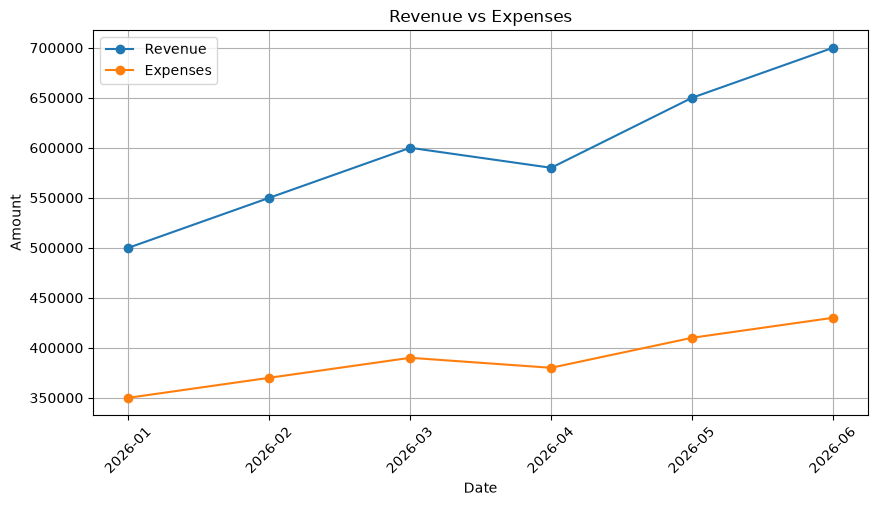

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(cleaned_df["Date"], cleaned_df["Revenue"], marker="o", label="Revenue")
plt.plot(cleaned_df["Date"], cleaned_df["Expenses"], marker="o", label="Expenses")

plt.title("Revenue vs Expenses")
plt.xlabel("Date")
plt.ylabel("Amount")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

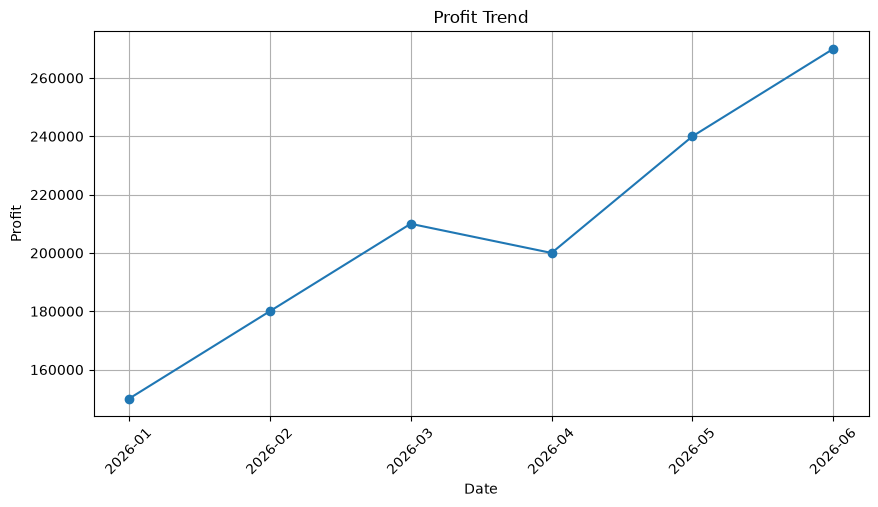

In [18]:
plt.figure(figsize=(10, 5))

plt.plot(
    cleaned_df["Date"],
    cleaned_df["Profit"],
    marker="o"
)

plt.title("Profit Trend")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

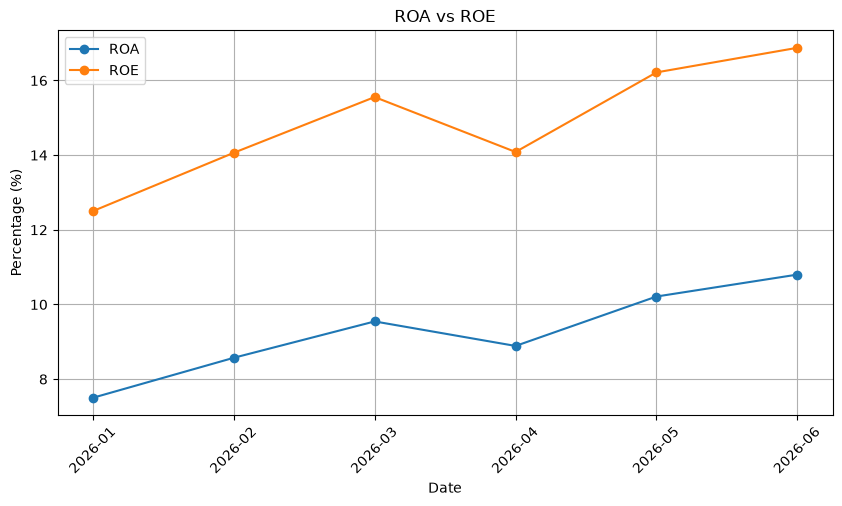

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(
    cleaned_df["Date"],
    cleaned_df["ROA_%"],
    marker="o",
    label="ROA"
)

plt.plot(
    cleaned_df["Date"],
    cleaned_df["ROE_%"],
    marker="o",
    label="ROE"
)

plt.title("ROA vs ROE")
plt.xlabel("Date")
plt.ylabel("Percentage (%)")
plt.legend()
plt.xticks(rotation=45)
plt.grid(True)

plt.show()

In [21]:
import pandas as pd

file_path = input("Enter the path of your CSV file: ")

user_df = pd.read_csv(file_path)

user_df.head()

KeyboardInterrupt: Interrupted by user

In [22]:
cleaned_df.to_csv("sample_financial_data.csv", index=False)

print("CSV file created successfully!")

CSV file created successfully!


In [23]:
uploaded_df = pd.read_csv("sample_financial_data.csv")

uploaded_df.head()

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%,ROA_%,ROE_%,Debt_to_Equity
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN,7.500000,12.500000,0.666667
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000,8.571429,14.062500,0.640625
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667,9.545455,15.555556,0.629630
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905,8.888889,14.084507,0.584507
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000,10.212766,16.216216,0.587838


In [24]:
def analyze_financial_data(df):

    # Create a copy so the original data is not changed
    df = df.copy()

    # Remove duplicate rows
    df = df.drop_duplicates()

    # Financial columns
    financial_columns = [
        "Revenue",
        "Expenses",
        "Assets",
        "Liabilities",
        "Equity"
    ]

    # Convert financial columns to numbers
    for column in financial_columns:
        df[column] = pd.to_numeric(
            df[column],
            errors="coerce"
        )

    # Fill missing financial values
    df[financial_columns] = df[financial_columns].fillna(0)

    # Financial calculations
    df["Profit"] = df["Revenue"] - df["Expenses"]

    df["Profit_Margin_%"] = (
        df["Profit"] / df["Revenue"]
    ) * 100

    df["Revenue_Growth_%"] = (
        df["Revenue"].pct_change()
    ) * 100

    df["Profit_Growth_%"] = (
        df["Profit"].pct_change()
    ) * 100

    df["ROA_%"] = (
        df["Profit"] / df["Assets"]
    ) * 100

    df["ROE_%"] = (
        df["Profit"] / df["Equity"]
    ) * 100

    df["Debt_to_Equity"] = (
        df["Liabilities"] / df["Equity"]
    )

    return df

In [25]:
analyzed_df = analyze_financial_data(uploaded_df)

analyzed_df

,Date,Revenue,Expenses,Assets,Liabilities,Equity,Profit,Profit_Margin,Revenue_Growth_%,Profit_Growth_%,ROA_%,ROE_%,Debt_to_Equity,Profit_Margin_%
0,2026-01,500000,350000,2000000,800000,1200000,150000,30.000000,NaN,NaN,7.500000,12.500000,0.666667,30.000000
1,2026-02,550000,370000,2100000,820000,1280000,180000,32.727273,10.000000,20.000000,8.571429,14.062500,0.640625,32.727273
2,2026-03,600000,390000,2200000,850000,1350000,210000,35.000000,9.090909,16.666667,9.545455,15.555556,0.629630,35.000000
3,2026-04,580000,380000,2250000,830000,1420000,200000,34.482759,-3.333333,-4.761905,8.888889,14.084507,0.584507,34.482759
4,2026-05,650000,410000,2350000,870000,1480000,240000,36.923077,12.068966,20.000000,10.212766,16.216216,0.587838,36.923077
5,2026-06,700000,430000,2500000,900000,1600000,270000,38.571429,7.692308,12.500000,10.800000,16.875000,0.562500,38.571429


In [26]:
most_profitable_month = analyzed_df.loc[analyzed_df["Profit"].idxmax()]

most_profitable_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [27]:
least_profitable_month = analyzed_df.loc[analyzed_df["Profit"].idxmin()]

least_profitable_month

Date                 2026-01
Revenue               500000
Expenses              350000
Assets               2000000
Liabilities           800000
Equity               1200000
Profit                150000
Profit_Margin           30.0
Revenue_Growth_%         NaN
Profit_Growth_%          NaN
ROA_%                    7.5
ROE_%                   12.5
Debt_to_Equity      0.666667
Profit_Margin_%         30.0
Name: 0, dtype: object

In [28]:
highest_revenue_month = analyzed_df.loc[analyzed_df["Revenue"].idxmax()]

highest_revenue_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [29]:
lowest_revenue_month = analyzed_df.loc[analyzed_df["Revenue"].idxmin()]

lowest_revenue_month

Date                 2026-01
Revenue               500000
Expenses              350000
Assets               2000000
Liabilities           800000
Equity               1200000
Profit                150000
Profit_Margin           30.0
Revenue_Growth_%         NaN
Profit_Growth_%          NaN
ROA_%                    7.5
ROE_%                   12.5
Debt_to_Equity      0.666667
Profit_Margin_%         30.0
Name: 0, dtype: object

In [30]:
highest_margin_month = analyzed_df.loc[analyzed_df["Profit_Margin_%"].idxmax()]

highest_margin_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [31]:
highest_roe_month = analyzed_df.loc[analyzed_df["ROE_%"].idxmax()]

highest_roe_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [32]:
highest_roa_month = analyzed_df.loc[analyzed_df["ROA_%"].idxmax()]

highest_roa_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [33]:
lowest_roa_month = analyzed_df.loc[analyzed_df["ROA_%"].idxmin()]

lowest_roa_month

Date                 2026-01
Revenue               500000
Expenses              350000
Assets               2000000
Liabilities           800000
Equity               1200000
Profit                150000
Profit_Margin           30.0
Revenue_Growth_%         NaN
Profit_Growth_%          NaN
ROA_%                    7.5
ROE_%                   12.5
Debt_to_Equity      0.666667
Profit_Margin_%         30.0
Name: 0, dtype: object

In [34]:
lowest_roe_month = analyzed_df.loc[analyzed_df["ROE_%"].idxmin()]

lowest_roe_month

Date                 2026-01
Revenue               500000
Expenses              350000
Assets               2000000
Liabilities           800000
Equity               1200000
Profit                150000
Profit_Margin           30.0
Revenue_Growth_%         NaN
Profit_Growth_%          NaN
ROA_%                    7.5
ROE_%                   12.5
Debt_to_Equity      0.666667
Profit_Margin_%         30.0
Name: 0, dtype: object

In [35]:
highest_debt_month = analyzed_df.loc[analyzed_df["Debt_to_Equity"].idxmax()]

highest_debt_month

Date                 2026-01
Revenue               500000
Expenses              350000
Assets               2000000
Liabilities           800000
Equity               1200000
Profit                150000
Profit_Margin           30.0
Revenue_Growth_%         NaN
Profit_Growth_%          NaN
ROA_%                    7.5
ROE_%                   12.5
Debt_to_Equity      0.666667
Profit_Margin_%         30.0
Name: 0, dtype: object

In [36]:
lowest_debt_month = analyzed_df.loc[analyzed_df["Debt_to_Equity"].idxmin()]

lowest_debt_month

Date                  2026-06
Revenue                700000
Expenses               430000
Assets                2500000
Liabilities            900000
Equity                1600000
Profit                 270000
Profit_Margin       38.571429
Revenue_Growth_%     7.692308
Profit_Growth_%          12.5
ROA_%                    10.8
ROE_%                  16.875
Debt_to_Equity         0.5625
Profit_Margin_%     38.571429
Name: 5, dtype: object

In [37]:
print("Financial Analysis Summary")
print("-------------------------")
print("Highest Revenue Month:", highest_revenue_month["Date"])
print("Lowest Revenue Month:", lowest_revenue_month["Date"])
print("Highest Profit Margin Month:", highest_margin_month["Date"])
print("Highest ROE Month:", highest_roe_month["Date"])
print("Lowest ROE Month:", lowest_roe_month["Date"])
print("Highest ROA Month:", highest_roa_month["Date"])
print("Lowest ROA Month:", lowest_roa_month["Date"])
print("Highest Debt-to-Equity Month:", highest_debt_month["Date"])
print("Lowest Debt-to-Equity Month:", lowest_debt_month["Date"])

Financial Analysis Summary
-------------------------
Highest Revenue Month: 2026-06
Lowest Revenue Month: 2026-01
Highest Profit Margin Month: 2026-06
Highest ROE Month: 2026-06
Lowest ROE Month: 2026-01
Highest ROA Month: 2026-06
Lowest ROA Month: 2026-01
Highest Debt-to-Equity Month: 2026-01
Lowest Debt-to-Equity Month: 2026-06


In [38]:
analyzed_df.to_csv("financial_analysis_final.csv", index=False)

print("Final financial analysis file saved successfully!")

Final financial analysis file saved successfully!


In [39]:
print("PROJECT CONCLUSION")
print("------------------")
print("The financial analysis shows that the company improved its overall")
print("financial performance during the six-month period.")
print("June 2026 recorded the highest revenue and profit.")
print("Profitability ratios such as ROA and ROE also reached their")
print("highest levels in June, while Debt-to-Equity was at its lowest.")
print("Overall, the company showed improving profitability and a")
print("stronger financial position toward the end of the period.")

PROJECT CONCLUSION
------------------
The financial analysis shows that the company improved its overall
financial performance during the six-month period.
June 2026 recorded the highest revenue and profit.
Profitability ratios such as ROA and ROE also reached their
highest levels in June, while Debt-to-Equity was at its lowest.
Overall, the company showed improving profitability and a
stronger financial position toward the end of the period.


In [40]:
print("PROJECT CONCLUSION")
print("------------------")

print(
    f"The financial analysis covers the period from {analyzed_df['Date'].iloc[0]} "
    f"to {analyzed_df['Date'].iloc[-1]}."
)

print(
    f"The highest revenue was recorded in {highest_revenue_month['Date']}, "
    f"with revenue of {highest_revenue_month['Revenue']:,.0f}."
)

print(
    f"The highest profit margin was recorded in {highest_margin_month['Date']}, "
    f"at {highest_margin_month['Profit_Margin_%']:.2f}%."
)

print(
    f"The highest ROE was recorded in {highest_roe_month['Date']}, "
    f"at {highest_roe_month['ROE_%']:.2f}%."
)

print(
    f"The highest ROA was recorded in {highest_roa_month['Date']}, "
    f"at {highest_roa_month['ROA_%']:.2f}%."
)

print(
    f"The highest debt-to-equity ratio was recorded in {highest_debt_month['Date']}, "
    f"at {highest_debt_month['Debt_to_Equity']:.2f}."
)

print(
    f"The lowest debt-to-equity ratio was recorded in {lowest_debt_month['Date']}, "
    f"at {lowest_debt_month['Debt_to_Equity']:.2f}."
)

print("Overall, the analysis provides insights into the company's profitability,")
print("financial performance, and debt position.")

PROJECT CONCLUSION
------------------
The financial analysis covers the period from 2026-01 to 2026-06.
The highest revenue was recorded in 2026-06, with revenue of 700,000.
The highest profit margin was recorded in 2026-06, at 38.57%.
The highest ROE was recorded in 2026-06, at 16.88%.
The highest ROA was recorded in 2026-06, at 10.80%.
The highest debt-to-equity ratio was recorded in 2026-01, at 0.67.
The lowest debt-to-equity ratio was recorded in 2026-06, at 0.56.
Overall, the analysis provides insights into the company's profitability,
financial performance, and debt position.
